In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [16]:
RANDOM_SEED = 42
# CSV_PATH = "hf://datasets/scikit-learn/churn-prediction/dataset.csv"
CSV_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [21]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# DATA UNDERSTANDING

In [6]:
df.head()

NameError: name 'df' is not defined

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
target_cols = 'Churn'
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.to_list()

print(f'Target column: {target_cols}')
print(f'Numerical column: {num_cols}')
print(f'Categorical column: {cat_cols}')

Target column: Churn
Numerical column: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical column: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Check the categorical data type (Binary, Ordinal, or Nominal)

In [14]:
for i in cat_cols:
    if df[i].nunique() == 2:
        print(f'{i}:{df[i].unique()}\n')

gender:['Female' 'Male']

Partner:['Yes' 'No']

Dependents:['No' 'Yes']

PhoneService:['No' 'Yes']

PaperlessBilling:['Yes' 'No']

Churn:['No' 'Yes']



In [15]:
for i in cat_cols:
    if df[i].nunique() == 3:
        print(f'{i}:{df[i].unique()}\n')

MultipleLines:['No phone service' 'No' 'Yes']

InternetService:['DSL' 'Fiber optic' 'No']

OnlineSecurity:['No' 'Yes' 'No internet service']

OnlineBackup:['Yes' 'No' 'No internet service']

DeviceProtection:['No' 'Yes' 'No internet service']

TechSupport:['No' 'Yes' 'No internet service']

StreamingTV:['No' 'Yes' 'No internet service']

StreamingMovies:['No' 'Yes' 'No internet service']

Contract:['Month-to-month' 'One year' 'Two year']



In [16]:
for i in cat_cols:
    if df[i].nunique() == 4:
        print(f'{i}:{df[i].unique()}\n')

PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']



In [17]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


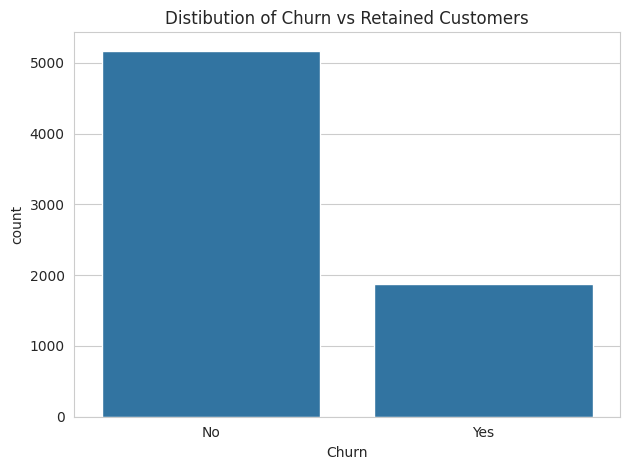

In [18]:
sns.countplot(x='Churn', data=df)
plt.title('Distibution of Churn vs Retained Customers')
plt.tight_layout()

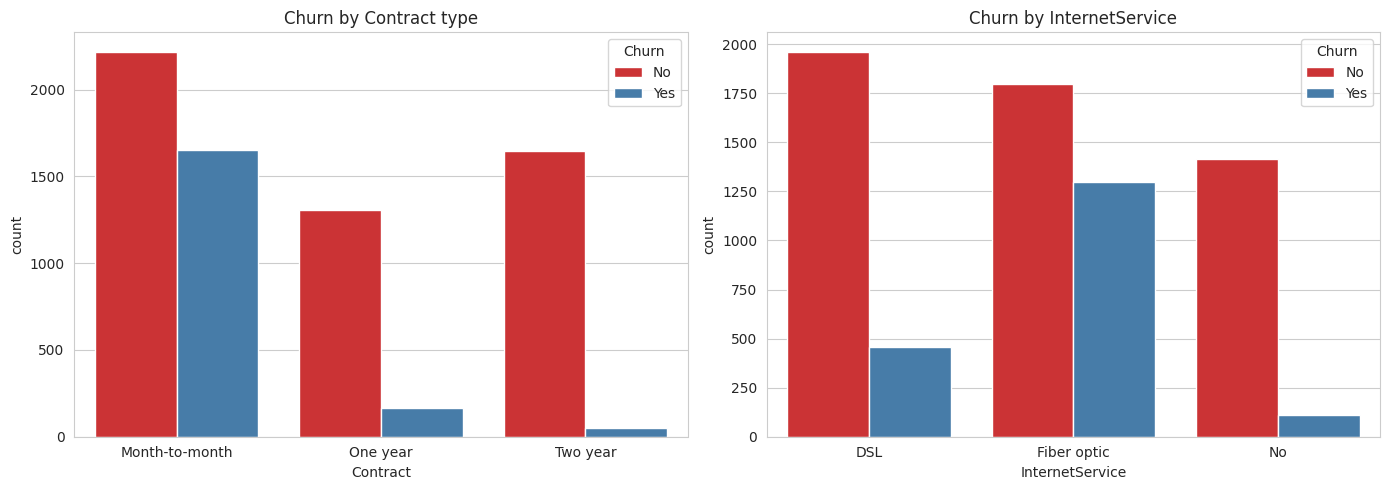

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Churn by Contract type')

sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Churn by InternetService')

plt.tight_layout()

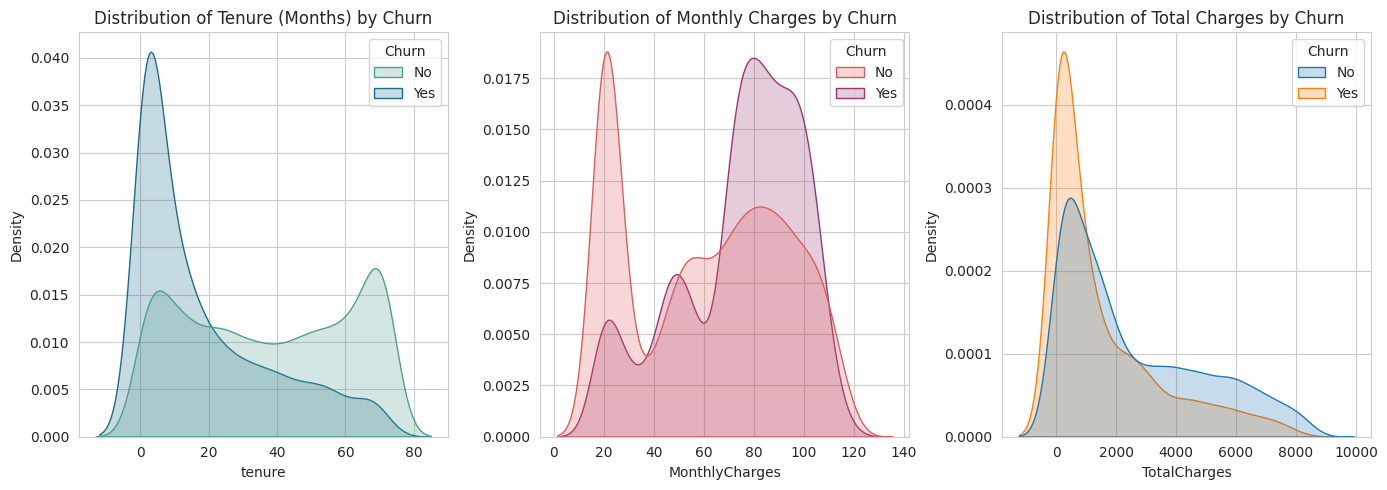

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest', ax=axes[0])
axes[0].set_title('Distribution of Tenure (Months) by Churn')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='flare', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges by Churn')

sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False, ax=axes[2])
axes[2].set_title('Distribution of Total Charges by Churn')

plt.tight_layout()

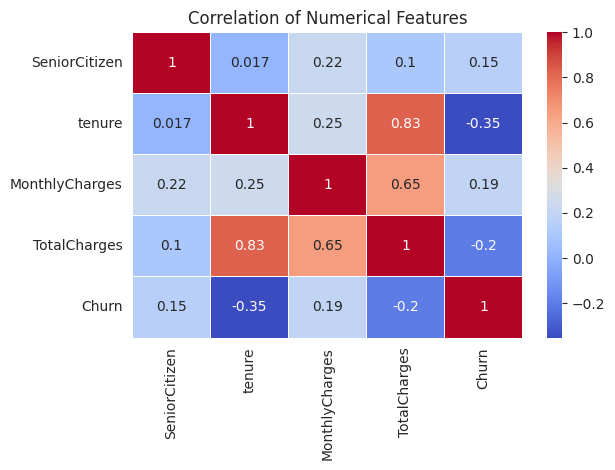

In [21]:
num_df = df[num_cols].copy()
num_df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation of Numerical Features')
plt.tight_layout()

Insight:
1. No missing values
2. The data is imbalance
3. Categorical Columns:
    * Binary = `target`, gender, Partner, Dependents, PhoneService, PaperlessBilling
    * Ordinal = Contract
    * Nominal = PaymentMethod, InternetService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

# DATA PREPARATION

In [22]:
# Binary
bin_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# Nominal
nom_cols = ['PaymentMethod', 'InternetService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Ordinal
ord_cols = ['Contract']
contract_order = [['Month-to-month', 'One year', 'Two year']]

In [23]:
type(df['TotalCharges'][0])

numpy.float64

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('bin', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), bin_cols),
        ('ord', OrdinalEncoder(categories=contract_order, handle_unknown='use_encoded_value', unknown_value=-1), ord_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [25]:
# Splitting Data to X and y
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No':0, 'Yes':1})

In [26]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

In [27]:
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

# MODELING

In [32]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_clf = XGBClassifier( n_estimators=300, learning_rate=0.05, max_depth=4, scale_pos_weight=neg / pos,
                         eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_clf.fit(X_train_t, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

# MODEL EVALUATION

In [34]:
xgb_clf.score(X_test_t, y_test)

0.7579843860894251